## Analisis Exploratorio 

Carga de datos

In [1]:
import os
os.getcwd()



'e:\\Modulo 5\\OnlineRetail-MLops'

In [13]:
from pathlib import Path
import pandas as pd

# Detecta la carpeta raíz del proyecto a partir de la ubicación del notebook
base_dir = Path.cwd()
if base_dir.name == "OnlineRetail-MLops":
    project_dir = base_dir
else:
    project_dir = base_dir / "OnlineRetail-MLops"

# Busca el archivo dentro de data/raw
raw_dir = project_dir / "data" / "raw"
files = list(raw_dir.glob("*.xlsx"))

if files:
    file_path = files[0]   # toma el primer archivo encontrado
    print("Usando archivo:", file_path)
    df = pd.read_excel(file_path)
    print(df.head())
else:
    raise FileNotFoundError(f"No se encontró ningún archivo .xlsx en {raw_dir}")

Usando archivo: e:\Modulo 5\OnlineRetail-MLops\data\raw\Online%20Retail.xlsx
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  


## Analisis del Dataset

In [10]:
# Dimensiones del dataset
print("Dimensiones:", df.shape)

# Tipos de datos
print("\nTipos de datos:\n", df.dtypes)

# Valores nulos por columna
print("\nValores nulos:\n", df.isnull().sum())

# Duplicados
print("\nDuplicados:", df.duplicated().sum())

# Estadísticas descriptivas
print("\nEstadísticas descriptivas:\n", df.describe(include="all"))


Dimensiones: (541909, 8)

Tipos de datos:
 InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object

Valores nulos:
 InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Duplicados: 5268

Estadísticas descriptivas:
         InvoiceNo StockCode                         Description  \
count    541909.0    541909                              540455   
unique    25900.0      4070                                4223   
top      573585.0    85123A  WHITE HANGING HEART T-LIGHT HOLDER   
freq       1114.0      2313                                2369   
mean          NaN       NaN                                 NaN   
min           NaN       NaN                     

## Hazgos clave
Dimensiones: 541,909 filas y 8 columnas

Nulos:

Description: 1,454 faltantes (probablemente productos sin descripción).

CustomerID: 135,080 faltantes (~25% del dataset). Esto es crítico porque afecta segmentación de clientes.

Duplicados: 5,268 registros repetidos → conviene eliminarlos en la limpieza.

Outliers:

Quantity: mínimo -80,995 y máximo 80,995 → hay devoluciones (negativos) y cantidades absurdamente altas.

UnitPrice: mínimo -11,062 y máximo 38,970 → precios negativos y valores extremos.

Categorías:

Country: 38 países, con fuerte concentración en United Kingdom (495,478 transacciones).

## Distribuciones y outliers

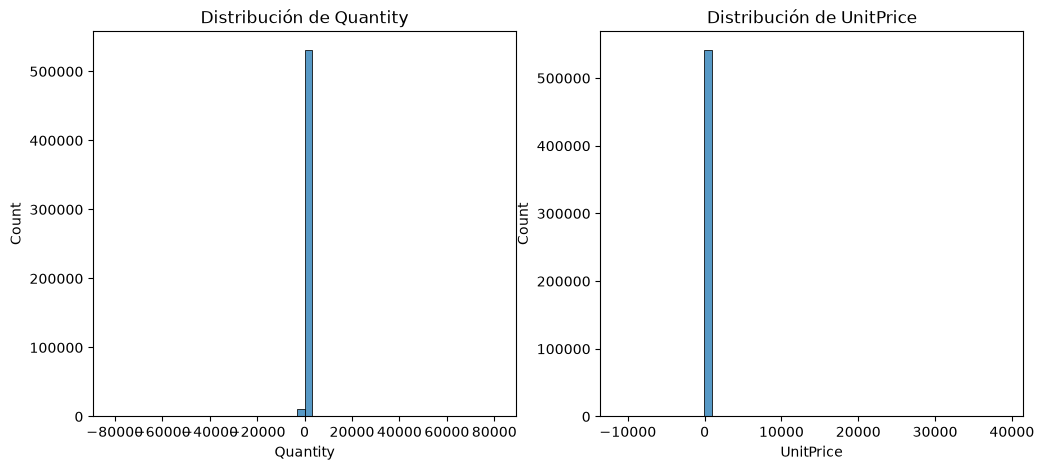

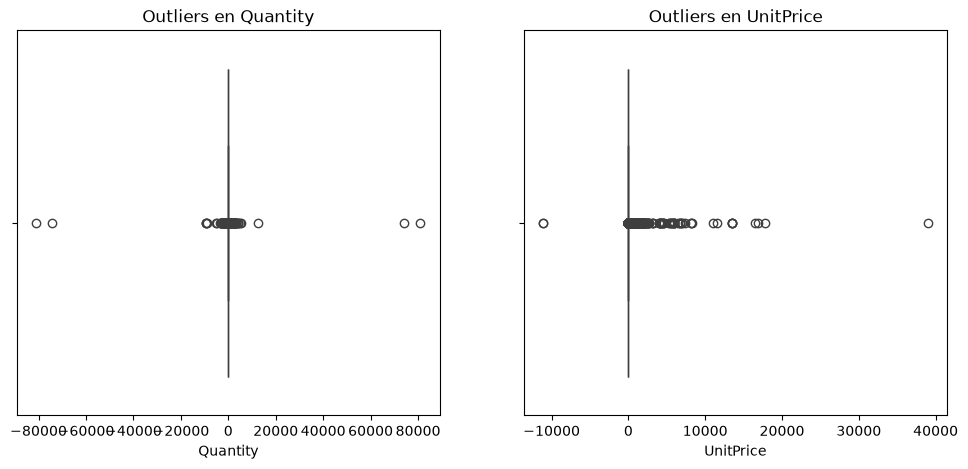

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histogramas
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.histplot(df["Quantity"], bins=50, ax=axes[0])
axes[0].set_title("Distribución de Quantity")

sns.histplot(df["UnitPrice"], bins=50, ax=axes[1])
axes[1].set_title("Distribución de UnitPrice")
plt.show()

# Boxplots para detectar outliers
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.boxplot(x=df["Quantity"], ax=axes[0])
axes[0].set_title("Outliers en Quantity")

sns.boxplot(x=df["UnitPrice"], ax=axes[1])
axes[1].set_title("Outliers en UnitPrice")
plt.show()


## Hallazgo
Quantity:

La mayoría de las transacciones son pequeñas (1–10 unidades).

Existen valores negativos (devoluciones) y cantidades absurdamente grandes (80,000).

UnitPrice:

La mayoría de los precios están entre 1 y 5.

Hay precios negativos (errores de carga) y valores muy altos (hasta 38,970).

Esto confirma que en la fase de limpieza debera definir reglas como:

Eliminar registros con Quantity <= 0.

Eliminar registros con UnitPrice <= 0.

Posiblemente filtrar outliers extremos (ej. Quantity > 1000 o UnitPrice > 1000).

## Detección de Outliers

In [12]:
def detectar_outliers(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers detectados")
    return outliers

outliers_quantity = detectar_outliers("Quantity")
outliers_unitprice = detectar_outliers("UnitPrice")


Quantity: 58619 outliers detectados
UnitPrice: 39627 outliers detectados


* Dimensiones iniciales: (541909, 8)
* Duplicados: 5268
* Nulos por columna:
- InvoiceNo           0
- StockCode           0
- Description      1454
- Quantity            0
- InvoiceDate         0
- UnitPrice           0
- CustomerID     135080
- Country             0
- dtype: int64
* Se cambio el Invoice Date a formato datetime
* Duplicados eliminados: 5268
* Registros con Quantity <= 0 eliminados: 10587
* Registros con UnitPrice <= 0 eliminados: 1176
* Outliers eliminados: 170
* Registros sin CustomerID eliminados: 132151
* Registros sin Description eliminados: 0
✅ Dataset limpio guardado en: data\clean\online_retail_clean.csv
* Dimensiones finales: (392557, 8)

## Explicación de las descisiones tomadas para la limpieza

* Conversión de Fechas (InvoiceDate): Las cadenas de texto con fechas y horas impiden realizar cálculos temporales. Convertir esta columna a tipo datetime64 estandariza el formato y permite extraer variables clave (día, mes, hora) en etapas posteriores de Feature Engineering. Eliminar los valores nulos (NaT) resultantes previene fallos en agrupaciones temporales. 
* Eliminar Duplicados (drop_duplicates): En este dataset, los registros idénticos representan errores de captura en el sistema de ventas o re-intentos de red por fallos en la transacción. Mantenerlos inflaría artificialmente las métricas de ingresos globales y el volumen total vendido. 
* Eliminar Cantidades $\le$ 0 (Quantity): Los valores negativos o cero en Quantity corresponden a cancelaciones de pedidos, devoluciones de clientes o ajustes de inventario por pérdidas/daños. Dado que el objetivo suele ser analizar transacciones de venta activas, estas filas deben filtrarse para no distorsionar el cálculo del valor del ciclo de vida del cliente (CLV) ni generar ingresos negativos.
* Eliminar Precios $\le$ 0 (UnitPrice): Los artículos con precio cero o negativo corresponden a ajustes administrativos internos, muestras gratuitas, regalos promocionales o errores del sistema transaccional. Deben eliminarse porque distorsionan la distribución de precios y anulan los cálculos de métricas como el ticket promedio (AOV). 
* Truncar Outliers Extremos ($> 10\,000$): Transacciones aisladas con cantidades o precios atípicamente altos suelen ser compras al por mayor atípicas o errores de digitación manual. Estos valores sesgan fuertemente los modelos de Machine Learning (como las regresiones) al desplazar las medias y aumentar drásticamente la varianza de los datos.
* Eliminar Registros sin CustomerID: La falta de ID de cliente ocurre en transacciones donde la compra se procesó como invitado. Si el objetivo del pipeline de MLOps incluye segmentación de clientes (Clustering/RFM) o predicción de retención (Churn), estos registros no aportan valor utilizable al no poder vincularse a un historial de compra único.
* Eliminar Registros sin Description: La ausencia de descripción del producto indica registros de transacciones incompletos o registros de prueba en el sistema. Al ser una columna descriptiva clave, su omisión suele correlacionarse con anomalías en la captura de datos.